In [1]:
import solver
import file_manager as fm
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

importlib.reload(solver)
importlib.reload(fm)
C1Result = fm.C1Result

In [30]:
results = [
    C1Result.load(path)
    for path in Path("seeds").glob("*.npz")
]

table = pd.DataFrame(result.row() for result in results)
table = table.drop(columns=["file", "ode_nfev", "ode_njev", "ode_nlu", "ode_message"], errors="ignore")
table = table.sort_values(["eM", "q"])
display(table)

,eM,q,p_amp,p_phase,charge_residual,Re_Phi_U_1,Im_Phi_U_1,residual_norm,max_residual,inf_xi,...,max_domega,min_r,rV_0,rU_0,interpolated_min_focusing,matching_ok,xi_ok,rU_ok,finite,valid
2,35.0,1.0,4,4,-7.304795e-09,-4.647442e-07,3.803055e-08,4.663549e-07,4.647442e-07,0.005365,...,3.119567,0.005365,3.235203,-0.077275,1.036752e-07,True,True,True,True,True
4,40.0,1.0,4,4,4.983163e-10,-5.105444e-07,-4.689268e-08,5.126936e-07,5.105444e-07,0.005360,...,2.675717,0.005360,3.231715,-0.077358,9.813280e-08,True,True,True,True,True
7,45.0,1.0,4,4,6.034718e-09,-5.475091e-07,-1.083369e-07,5.581572e-07,5.475091e-07,0.004364,...,2.331539,0.004364,3.233546,-0.077315,9.274809e-08,True,True,True,True,True
5,50.0,1.0,4,4,4.932548e-09,-5.812034e-07,-1.727531e-07,6.063542e-07,5.812034e-07,0.004233,...,2.057247,0.004233,3.234420,-0.077294,8.836957e-08,True,True,True,True,True
6,55.0,1.0,4,4,-1.581587e-10,-6.189946e-07,-2.339301e-07,6.617233e-07,6.189946e-07,0.004209,...,1.841783,0.004209,3.237315,-0.077224,8.293546e-08,True,True,True,True,True
1,60.0,1.0,4,4,-3.248610e-09,-6.489083e-07,-2.885444e-07,7.101763e-07,6.489083e-07,0.004247,...,1.655311,0.004247,3.238224,-0.077203,8.004216e-08,True,True,True,True,True
9,65.0,1.0,4,4,-6.866117e-09,-6.710174e-07,-3.384856e-07,7.515876e-07,6.710174e-07,0.000615,...,1.502568,0.000615,3.249438,-0.076936,7.525013e-08,True,True,True,True,True
0,70.0,1.0,4,4,2.559181e-09,-6.876925e-07,-3.759857e-07,7.837683e-07,6.876925e-07,0.004189,...,1.375239,0.004189,3.243517,-0.077077,7.208859e-08,True,True,True,True,True
10,75.0,1.0,4,4,-7.573288e-10,-7.023968e-07,-4.313177e-07,8.242553e-07,7.023968e-07,0.001432,...,1.264528,0.001432,3.252800,-0.076857,6.802971e-08,True,True,True,True,True
8,80.0,1.0,4,4,-7.902530e-10,-7.348907e-07,-4.730612e-07,8.739862e-07,7.348907e-07,0.000166,...,1.161690,0.000166,3.257423,-0.076748,6.535663e-08,True,True,True,True,True


In [31]:
for result in results:
    result.evaluate(
        solver.tanh_ansatz,
        solver.omega_domega,
        solver.rplus_and_Qtarget,
        n_grid=10001,
        n_profile=10001,
    )

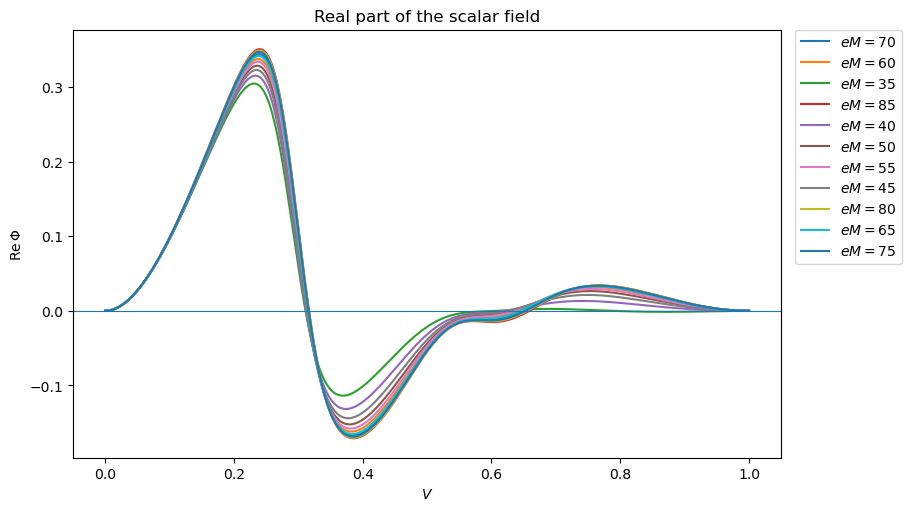

In [34]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

for result in results:
    out = result.validation

    ax.plot(
        out["V"],
        out["Phi"].real,
        label=rf"$eM={result.eM:g}$",
    )

ax.axhline(0.0, linewidth=0.8)
ax.set_xlabel(r"$V$")
ax.set_ylabel(r"$\mathrm{Re}\,\Phi$")
ax.set_title("Real part of the scalar field")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

plt.show()

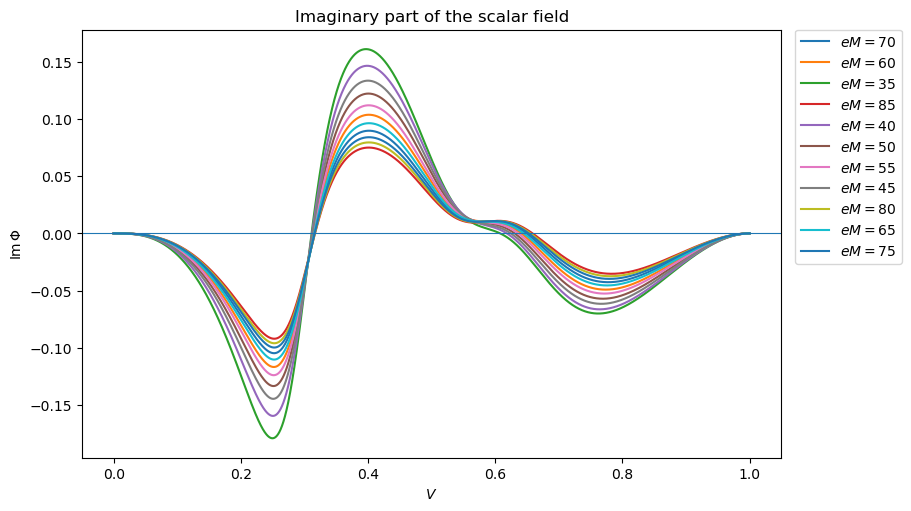

In [35]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

for result in results:
    out = result.validation

    ax.plot(
        out["V"],
        out["Phi"].imag,
        label=rf"$eM={result.eM:g}$",
    )

ax.axhline(0.0, linewidth=0.8)
ax.set_xlabel(r"$V$")
ax.set_ylabel(r"$\mathrm{Im}\,\Phi$")
ax.set_title("Imaginary part of the scalar field")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

plt.show()